## Paper Title: Improved Facial Biometric Authentication Using MobileNetV2 

### Implementation Summary  

This notebook conatins the implementation of **MobileNetV2-based transfer learning anti-spoofing model proposed in the paper** using the **NUAA face anti-spoofing dataset**.

#### What is implemented from the paper:
The following major components of the paper are implemented:

- **NUAA dataset preparation from raw split text files**
- **Binary classification setup: real vs fake**
- **MobileNetV2 pretrained on ImageNet**
- **Transfer learning based training**
- **Custom binary classification head**
- **30% validation split**
- **Batch size = 25**
- **Stage-wise training and fine-tuning**
- **Performance evaluation using**: accuracy, precision, recall, F1-score, confusion matrix
- **Sample prediction testing**

This implementation directly reproduces the paper’s main experimental pipeline.

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
dataset_root  = "/Users/pranjalrathod/Documents/PRANJAL/SVNIT/YEARS/1ST YEAR/2ND SEMESTER/MINI PROJECT/PAPER 4/dataset/NUAA"
prepared_root = "/Users/pranjalrathod/Documents/PRANJAL/SVNIT/YEARS/1ST YEAR/2ND SEMESTER/MINI PROJECT/PAPER 4/dataset/NUAA_READY"

IMG_SIZE = 224
BATCH_SIZE = 25
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 10

In [3]:
print("Dataset root exists:", os.path.exists(dataset_root))

print("\nFiles/folders inside dataset_root:")
for item in os.listdir(dataset_root):
    print(item)

Dataset root exists: True

Files/folders inside dataset_root:
.DS_Store
client_train_raw.txt
imposter_train_raw.txt
imposter_test_raw.txt
client_test_raw.txt
ClientRaw
ImposterRaw


In [4]:
for split in ["train", "test"]:
    for cls in ["real", "fake"]:
        os.makedirs(os.path.join(prepared_root, split, cls), exist_ok=True)

def resolve_local_path(line, dataset_root):

    line = line.strip().replace("\\", "/")

    if "ClientRaw/" in line:
        subpath = line.split("ClientRaw/", 1)[1]
        return os.path.join(dataset_root, "ClientRaw", subpath)

    elif "ImposterRaw/" in line:
        subpath = line.split("ImposterRaw/", 1)[1]
        return os.path.join(dataset_root, "ImposterRaw", subpath)

    return None

def copy_from_split_file(txt_file, dest_folder):
    copied = 0
    missing = 0
    missing_examples = []

    with open(txt_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:
        src = resolve_local_path(line, dataset_root)

        if src and os.path.exists(src):
            dst = os.path.join(dest_folder, os.path.basename(src))
            shutil.copy(src, dst)
            copied += 1
        else:
            missing += 1
            if len(missing_examples) < 5:
                missing_examples.append(line)

    return copied, missing, missing_examples

# real images
copied1, missing1, ex1 = copy_from_split_file(
    os.path.join(dataset_root, "client_train_raw.txt"),
    os.path.join(prepared_root, "train", "real")
)

copied2, missing2, ex2 = copy_from_split_file(
    os.path.join(dataset_root, "client_test_raw.txt"),
    os.path.join(prepared_root, "test", "real")
)

# fake images
copied3, missing3, ex3 = copy_from_split_file(
    os.path.join(dataset_root, "imposter_train_raw.txt"),
    os.path.join(prepared_root, "train", "fake")
)

copied4, missing4, ex4 = copy_from_split_file(
    os.path.join(dataset_root, "imposter_test_raw.txt"),
    os.path.join(prepared_root, "test", "fake")
)

print("Dataset prepared successfully.")
print("Train real copied :", copied1, "| missing:", missing1)
print("Test real copied  :", copied2, "| missing:", missing2)
print("Train fake copied :", copied3, "| missing:", missing3)
print("Test fake copied  :", copied4, "| missing:", missing4)

print("\nMissing examples:")
print("Train real:", ex1)
print("Test real :", ex2)
print("Train fake:", ex3)
print("Test fake :", ex4)

Dataset prepared successfully.
Train real copied : 1743 | missing: 0
Test real copied  : 3362 | missing: 0
Train fake copied : 1748 | missing: 0
Test fake copied  : 5761 | missing: 0

Missing examples:
Train real: []
Test real : []
Train fake: []
Test fake : []


In [5]:
for split in ["train", "test"]:
    for cls in ["real", "fake"]:
        folder = os.path.join(prepared_root, split, cls)
        print(split, cls, len(os.listdir(folder)))

train real 1743
train fake 1748
test real 3362
test fake 5761


In [6]:
train_dir = os.path.join(prepared_root, "train")
test_dir = os.path.join(prepared_root, "test")

print("Train dir:", train_dir)
print("Test dir :", test_dir)

Train dir: /Users/pranjalrathod/Documents/PRANJAL/SVNIT/YEARS/1ST YEAR/2ND SEMESTER/MINI PROJECT/PAPER 4/dataset/NUAA_READY/train
Test dir : /Users/pranjalrathod/Documents/PRANJAL/SVNIT/YEARS/1ST YEAR/2ND SEMESTER/MINI PROJECT/PAPER 4/dataset/NUAA_READY/test


In [7]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.30,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [8]:
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 2445 images belonging to 2 classes.
Found 1046 images belonging to 2 classes.
Found 9123 images belonging to 2 classes.
Class indices: {'fake': 0, 'real': 1}


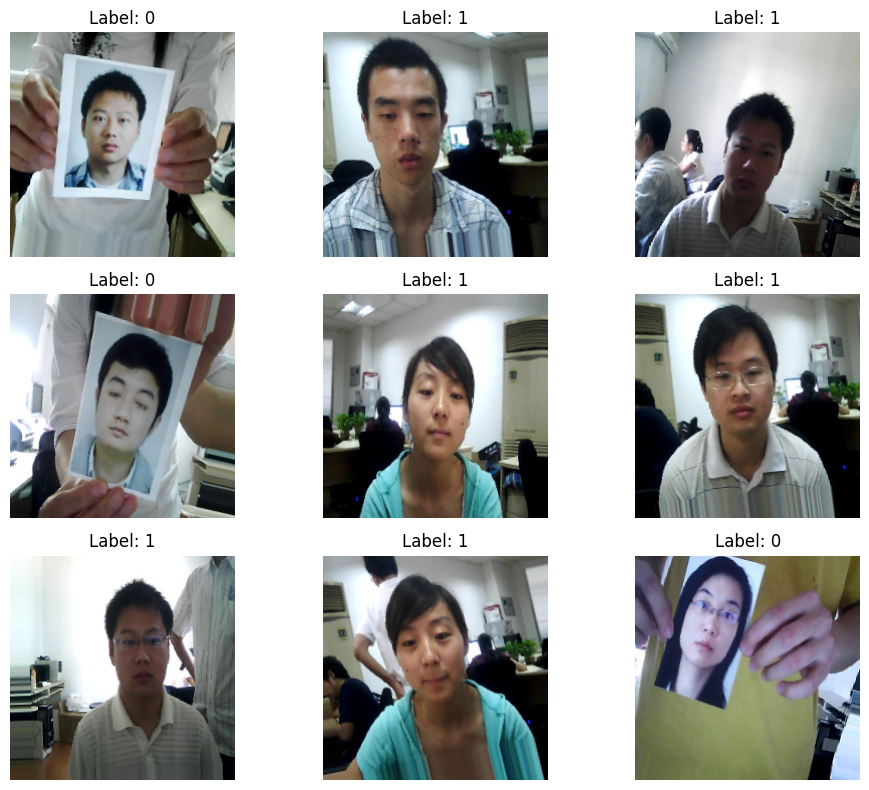

In [9]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    img = (images[i] + 1.0) / 2.0
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.30)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(e 2 papers?e 2pa
        filepath="best_mobilenetv2_nuaa.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [12]:
history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,pers?
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks
)

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.5927 - loss: 0.6885
Epoch 1: val_accuracy improved from None to 0.88719, saving model to best_mobilenetv2_nuaa.keras

Epoch 1: finished saving model to best_mobilenetv2_nuaa.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 392ms/step - accuracy: 0.6793 - loss: 0.5953 - val_accuracy: 0.8872 - val_loss: 0.4363 - learning_rate: 1.0000e-04
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8453 - loss: 0.4139
Epoch 2: val_accuracy improved from 0.88719 to 0.94646, saving model to best_mobilenetv2_nuaa.keras

Epoch 2: finished saving model to best_mobilenetv2_nuaa.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 389ms/step - accuracy: 0.8777 - loss: 0.3749 - val_accuracy: 0.9465 - val_loss: 0.3092 - learning_rate: 1.0000e-04
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9270 - loss: 0.2940
Epoch 3: val_accuracy improved from 0.94646 to 0.95220, saving model to best_mobilenetv2_nuaa.keras

Epoch 3: finished saving m

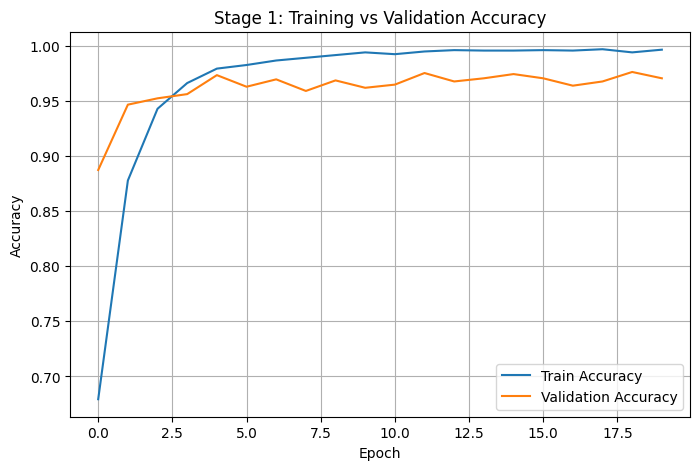

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history_stage1.history["accuracy"], label="Train Accuracy")
plt.plot(history_stage1.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 1: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

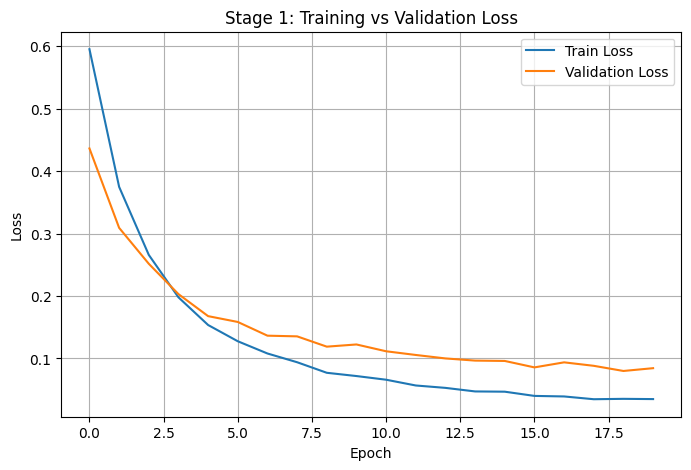

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history_stage1.history["loss"], label="Train Loss")
plt.plot(history_stage1.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_stage2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9104 - loss: 0.2177
Epoch 1: val_accuracy improved from None to 0.98566, saving model to best_mobilenetv2_nuaa.keras

Epoch 1: finished saving model to best_mobilenetv2_nuaa.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 56s 509ms/step - accuracy: 0.9607 - loss: 0.1299 - val_accuracy: 0.9857 - val_loss: 0.0485 - learning_rate: 1.0000e-05
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9940 - loss: 0.0463
Epoch 2: val_accuracy improved from 0.98566 to 0.99140, saving model to best_mobilenetv2_nuaa.keras

Epoch 2: finished saving model to best_mobilenetv2_nuaa.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 55s 563ms/step - accuracy: 0.9963 - loss: 0.0359 - val_accuracy: 0.9914 - val_loss: 0.0349 - learning_rate: 1.0000e-05
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9996 - loss: 0.0153
Epoch 3: val_accuracy did not improve from 0.99140
98/98 ━━━━━━━━━━━━━━━━━━━━ 47s 484ms/step - accuracy: 0.9992 - loss: 0.0149 

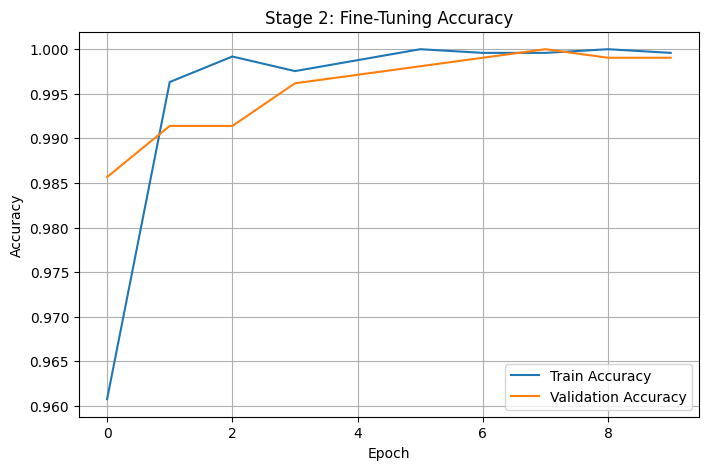

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history_stage2.history["accuracy"], label="Train Accuracy")
plt.plot(history_stage2.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 2: Fine-Tuning Accuracy")
plt.legend()
plt.grid(True)
plt.show()

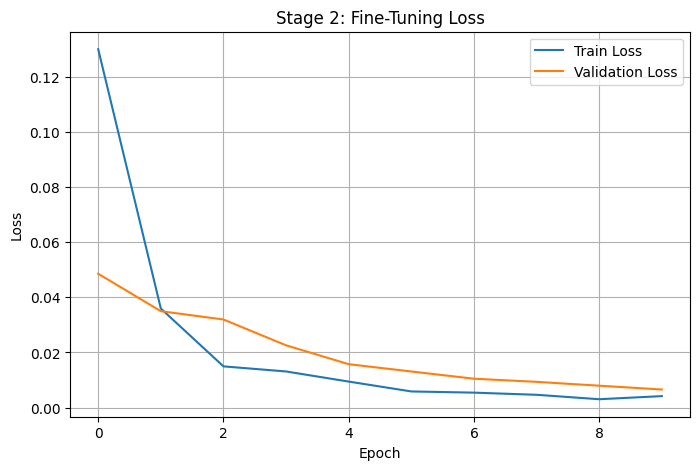

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history_stage2.history["loss"], label="Train Loss")
plt.plot(history_stage2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 2: Fine-Tuning Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print("Test Loss    :", test_loss)
print("Test Accuracy:", test_acc)

365/365 ━━━━━━━━━━━━━━━━━━━━ 105s 287ms/step - accuracy: 0.9570 - loss: 0.1169
Test Loss    : 0.11693599820137024
Test Accuracy: 0.9570316672325134


In [20]:
y_prob = model.predict(test_generator)
y_pred = (y_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

365/365 ━━━━━━━━━━━━━━━━━━━━ 97s 265ms/step


In [21]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

Accuracy : 0.9570316781760386
Precision: 0.896
Recall   : 0.9994051160023796
F1 Score : 0.9448818897637795


In [22]:
class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        fake       1.00      0.93      0.96      5761
        real       0.90      1.00      0.94      3362

    accuracy                           0.96      9123
   macro avg       0.95      0.97      0.95      9123
weighted avg       0.96      0.96      0.96      9123



In [23]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[5371  390]
 [   2 3360]]


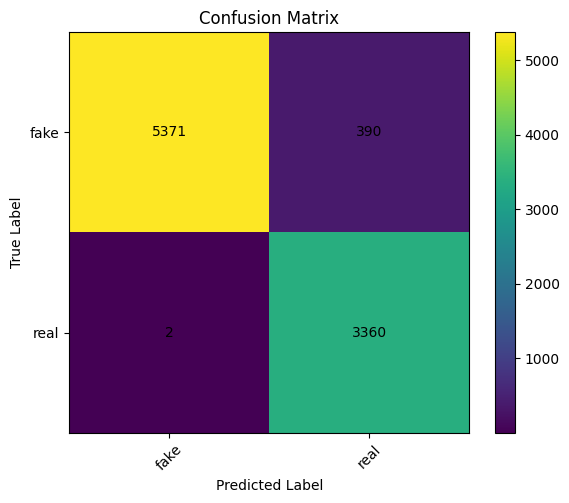

In [24]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [25]:
model.save("mobilenetv2_face_antispoofing.h5")
print("Model saved successfully.")

Model saved successfully.


In [26]:
from tensorflow.keras.models import load_model

loaded_model = load_model("mobilenetv2_face_antispoofing.h5")
print("Model loaded successfully.")

Model loaded successfully.


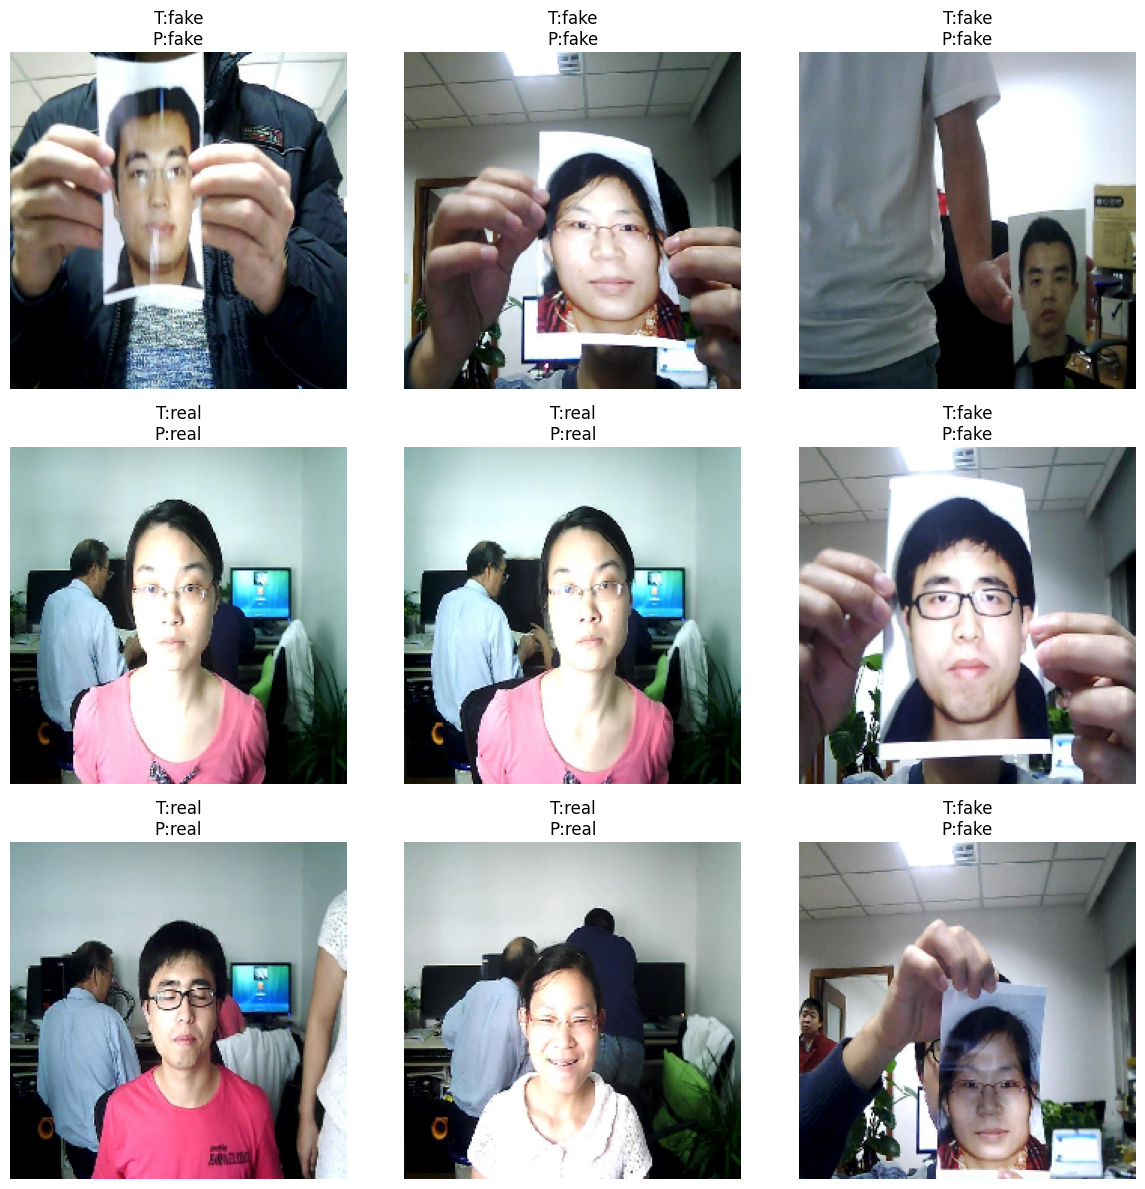

Correct predictions: 9/9
Accuracy on selected samples: 100.00%


In [28]:
real_folder = '/Users/pranjalrathod/Documents/PRANJAL/SVNIT/YEARS/1ST YEAR/2ND SEMESTER/MINI PROJECT/PAPER 4/dataset/NUAA_READY/test/real'
fake_folder = '/Users/pranjalrathod/Documents/PRANJAL/SVNIT/YEARS/1ST YEAR/2ND SEMESTER/MINI PROJECT/PAPER 4/dataset/NUAA_READY/test/fake'

num_real = 4
num_fake = 5

real_imgs = random.sample(os.listdir(real_folder), num_real)
fake_imgs = random.sample(os.listdir(fake_folder), num_fake)

test_samples = [(os.path.join(real_folder, x), "real") for x in real_imgs] + \
               [(os.path.join(fake_folder, x), "fake") for x in fake_imgs]

random.shuffle(test_samples)

plt.figure(figsize=(12, 12))

correct = 0

for i, (img_path, true_label) in enumerate(test_samples):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    pred = model.predict(img_array, verbose=0)[0][0]
    predicted_label = "real" if pred > 0.5 else "fake"

    if predicted_label == true_label:
        correct += 1

    plt.subplot(3, 3, i + 1)
    plt.imshow(load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE)))
    plt.title(f"T:{true_label}\nP:{predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Correct predictions: {correct}/{len(test_samples)}")
print(f"Accuracy on selected samples: {(correct/len(test_samples))*100:.2f}%")